Часть 2. Марковские цепи. Вычисление P^k и предельное распределение

In [2]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.9 MB/s eta 0:00:00


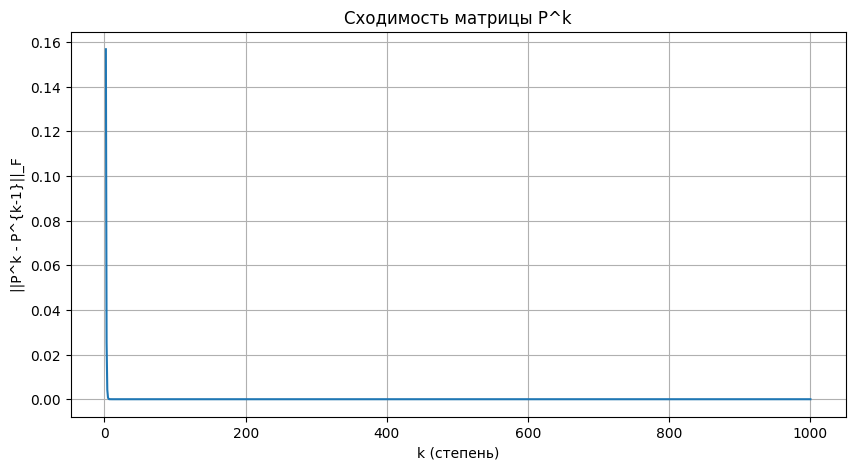

Строки матрицы P^1000 (должны быть одинаковы и равны π):
[[0.26512173 0.2529396  0.2446315  0.2373122 ]
 [0.26512173 0.2529396  0.24463149 0.23731219]
 [0.26512173 0.2529396  0.24463149 0.23731219]
 [0.26512173 0.2529396  0.2446315  0.2373122 ]]

Стационарное распределение π: [0.2651204  0.25293833 0.24463027 0.237311  ]
Максимальное отклонение строк P^1000 от π: 1.331898752787719e-06


In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Используем матрицу P из задания 5
P = np.array([[0.30165913, 0.20135747, 0.20173454, 0.29524887],
              [0.25316456, 0.31289557, 0.24841772, 0.18552215],
              [0.1995094 , 0.29026983, 0.31766149, 0.19255928],
              [0.30467762, 0.20817531, 0.2132322 , 0.27391488]])

# -Возведение в степень k=1..1000
k_values = np.arange(1, 1001)
P_powers = {}
norm_diff = []

P_prev = P.copy()
for k in k_values:

    if k == 1:
        Pk = P
    else:
        Pk = Pk @ P

    if k == 1000:
        P1000 = Pk

    if k > 1:
        norm_diff.append(np.linalg.norm(Pk - P_prev, 'fro'))
        P_prev = Pk
    else:
        norm_diff.append(np.nan)  # для k=1 нет разности

# -График стабилизации
plt.figure(figsize=(10,5))
plt.plot(k_values[1:], norm_diff[1:], linewidth=1.5)
plt.xlabel('k (степень)')
plt.ylabel('||P^k - P^{k-1}||_F')
plt.title('Сходимость матрицы P^k')
plt.grid(True)
plt.savefig("convergence.png", dpi=150)
plt.show()

# Проверка сходимости к π
pi = np.array([0.2651204, 0.25293833, 0.24463027, 0.237311])  # стационарное распределение из задания 5
print("Строки матрицы P^1000 (должны быть одинаковы и равны π):")
print(P1000)
print("\nСтационарное распределение π:", pi)
print("Максимальное отклонение строк P^1000 от π:",
      np.max(np.abs(P1000 - pi)))